In [1]:
#ЗАДАНИЕ 1 (КУБИКИ)
#Сгенерировать эксперимент, где бросается 10 кубиков и считается сумма выпавших очков на всех кубиках:
#Часть 1.
#Соберите выборку размера 20: Проведите эксперимент 20 раз. Каждый раз записывайте результат эксперимента.
#Постройте гистограмму плотности распределения
#Постройте график эмпирической плотность распределения
#Посчитайте точечную оценку мат. ожидания
#Посчитайте точечную оценку дисперсии

#Часть 2.
#Повторите расчеты для выборки размера 60, 100 и 1000.
#Сравните значение мат.ожидания и дисперсии. Объясните различие в результатах.

In [2]:
#ЧАСТЬ 1.
#Сначала делаем выборку
import random
import matplotlib.pyplot as plt
import numpy as np

#Функция одного броска кубика (сумма 10)
def roll_dice():
    return sum(random.randint(1, 6) for _ in range(10))

#20 раз бросаем бедный кубик
sample = [roll_dice() for _ in range(20)]
print("Результаты 20 экспериментов:")
print(sample)

Результаты 20 экспериментов:
[37, 33, 34, 25, 38, 40, 33, 28, 38, 41, 30, 28, 42, 35, 30, 31, 39, 45, 25, 30]


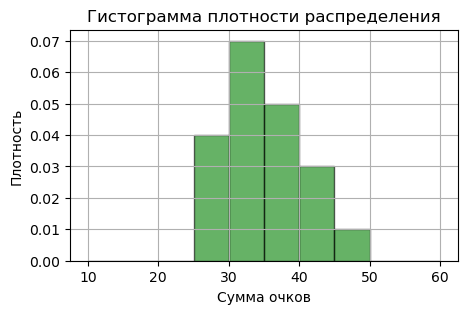

In [3]:
#Строим гистограмму
plt.figure(figsize=(5, 3))
plt.hist(sample, bins=range(10, 61, 5), density=True, alpha=0.6, color='g', edgecolor='black')
plt.title('Гистограмма плотности распределения')
plt.xlabel('Сумма очков')
plt.ylabel('Плотность')
plt.grid(True)
plt.show()

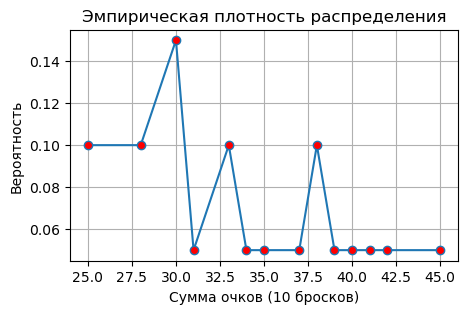

In [4]:
#Эмпирическая плотность
plt.figure(figsize=(5, 3))
unique, counts = np.unique(sample, return_counts=True)
probabilities = counts / len(sample)
plt.plot(unique, probabilities, 'o-', markerfacecolor='red')
plt.title('Эмпирическая плотность распределения')
plt.xlabel('Сумма очков (10 бросков)')
plt.ylabel('Вероятность')
plt.grid(True)
plt.show()

In [5]:
#Мат. ожидание
mean = np.mean(sample)
print(f"Точечная оценка математического ожидания: {mean:.2f}")

#Дисперсия
variance = np.var(sample, ddof=0)
#ddof=0 для выборочной дисперсии
print(f"Точечная оценка дисперсии: {variance:.2f}")

Точечная оценка математического ожидания: 34.10
Точечная оценка дисперсии: 31.49


Результаты для разных размеров выборки:


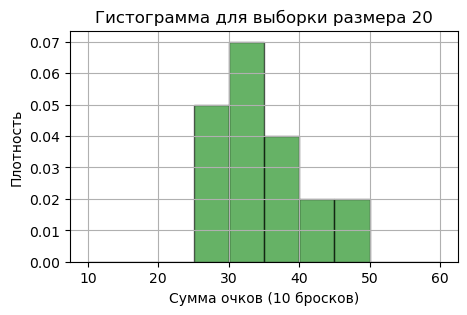


Размер выборки: 20
Математическое ожидание: 34.55
Дисперсия: 35.15


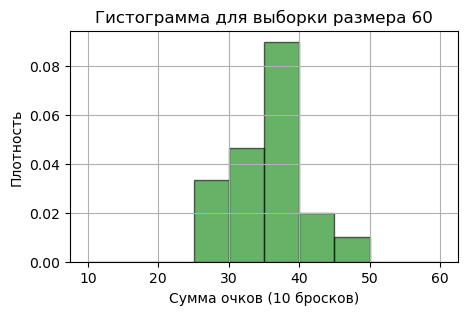


Размер выборки: 60
Математическое ожидание: 35.27
Дисперсия: 24.76


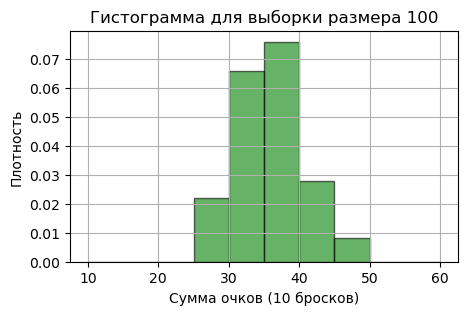


Размер выборки: 100
Математическое ожидание: 35.43
Дисперсия: 22.25


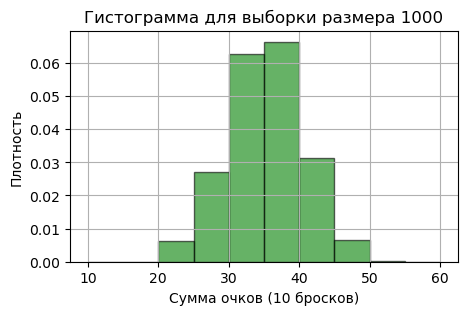


Размер выборки: 1000
Математическое ожидание: 34.73
Дисперсия: 28.10

Результаты для сравнения:
Размер выборки 20:
  Мат. ожидание: 34.55
  Дисперсия: 35.15
Размер выборки 60:
  Мат. ожидание: 35.27
  Дисперсия: 24.76
Размер выборки 100:
  Мат. ожидание: 35.43
  Дисперсия: 22.25
Размер выборки 1000:
  Мат. ожидание: 34.73
  Дисперсия: 28.10


In [6]:
#ЧАСТЬ 2.
#Функцию кубика берем с первой части

#Подготовка
#Фукнции эксперимента и анализа
def perform_experiment(sample_size):
    sample = [roll_dice() for _ in range(sample_size)]
    
    #Статистика
    mean = np.mean(sample)
    variance = np.var(sample, ddof=0)
    
    #Гистрограмма
    plt.figure(figsize=(5, 3))
    plt.hist(sample, bins=range(10, 61, 5), density=True, alpha=0.6, color='g', edgecolor='black')
    plt.title(f'Гистограмма для выборки размера {sample_size}')
    plt.xlabel('Сумма очков (10 бросков)')
    plt.ylabel('Плотность')
    plt.grid(True)
    plt.show()
    
    return mean, variance

#Теперь работаем для разных выборок. РАБОТА.
results = {}

print("Результаты для разных размеров выборки:")
for size in [20, 60, 100, 1000]:
    mean, variance = perform_experiment(size)
    results[size] = {'mean': mean, 'variance': variance}
    print(f"\nРазмер выборки: {size}")
    print(f"Математическое ожидание: {mean:.2f}")
    print(f"Дисперсия: {variance:.2f}")

print("\nРезультаты для сравнения:")
for size in results:
    print(f"Размер выборки {size}:")
    print(f"  Мат. ожидание: {results[size]['mean']:.2f}")
    print(f"  Дисперсия: {results[size]['variance']:.2f}")


In [7]:
#Для анализа возьмем ответы которые получились у меня при первой генерации:
#Размер выборки 20:
#  Мат. ожидание: 34.55
#  Дисперсия: 35.15
#Размер выборки 60:
#  Мат. ожидание: 35.27
#  Дисперсия: 24.76
#Размер выборки 100:
#  Мат. ожидание: 35.43
#  Дисперсия: 22.25
#Размер выборки 1000:
#  Мат. ожидание: 34.73
#  Дисперсия: 28.10

#Мат. ожидание
#При малых выборках (n=20) наблюдается значительное отклонение от теоретического значения (35.0)
#С увеличением размера выборки оценка становится более точной. Отклонение при n=60 составляет ±0.27. При n=100: ±0.43. При n=1000: ±0.27
#Для выборки в 1000 наблюдений оценка наиболее близка к теоретическому значению (больше выборка, соответственно больше чисел для анализа а значит меньше разброс значений)

#Дисперсия
#При малых выборках (n=20) дисперсия сильно завышена (35.15)
#С ростом выборки наблюдается стабилизация показателя: При n=60: 24.76; При n=100: 22.25; При n=1000: 28.10
#для выборки 1000 значение дисперсии ближе к теоретическому (≈29.2), чем для выборки 100

In [8]:
#ЗАДАНИЕ 2. Непрерывная случайная величина.
#Непрерывная случайная величина имеет распределение, заданное плотностью:
#(я не знаю как в джупитер вставить картинку, поэтому просто представим её)
#Докажите, что если f(x) плотность распределения, то k = 2/3 (Подсказка, нужно использовать одно из свойств функции плотности вероятностей);
#Нарисуйте график плотности распределения;
#Нарисуйте график интегральной функции распределения;

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, integrate, solve

#Найдем k из условия нормировки
x, k = symbols('x k')

#Заданная плотность
f_x = 3*(1 - x/k)

#Интеграл от плотности должен быть равен 1
integral = integrate(f_x, (x, 0, k))
equation = integral - 1

#Решаем уравнение
k_value = solve(equation, k)[0]  # Добавляем [0] для получения первого решения
print(f"Значение k: {k_value}")  # Должно быть 2/3

Значение k: 2/3


In [12]:
#Функция плотности
def density(x):
    if 0 <= x <= 2/3:
        return 3*(1 - x/(2/3))
    return 0

#Функция распределения
def distribution(x):
    if x < 0:
        return 0
    elif 0 <= x <= 2/3:
        return 3*x - (9/4)*x**2
    else:
        return 1

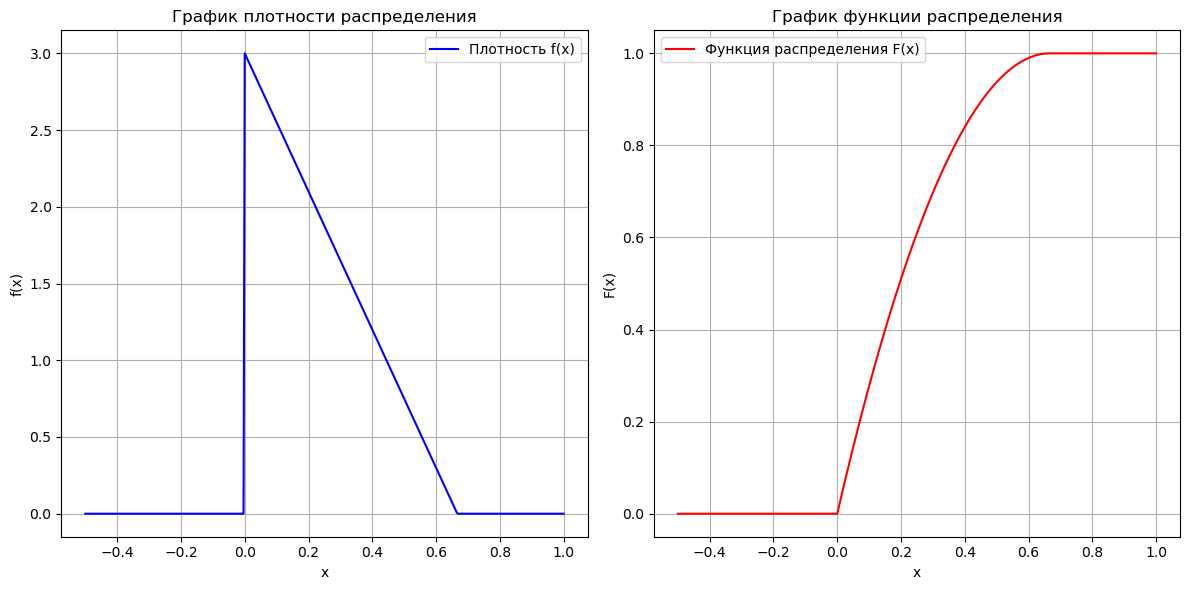

In [13]:
#Строим графики
x_values = np.linspace(-0.5, 1, 400)
density_values = [density(x) for x in x_values]
distribution_values = [distribution(x) for x in x_values]

#График плотности
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_values, density_values, label='Плотность f(x)', color='blue')
plt.title('График плотности распределения')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()

#График функции распределения
plt.subplot(1, 2, 2)
plt.plot(x_values, distribution_values, label='Функция распределения F(x)', color='red')
plt.title('График функции распределения')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
#ЗАДАНИЕ 3. Проанализировать датасет цветков ирисов
# https://www.kaggle.com/datasets/uciml/iris?resource=download
# https://ru.wikipedia.org/wiki/Ирисы_Фишера
#Часть 1
#Возьмите колонку с признаком «SepalLengthCm»
#Нарисуйте гистограмму этой колонки
#Посчитайте точечную оценку мат. ожидания и дисперсии

#Часть 2
#В данных присутствует три разных вида ириса. Разделите значения из признака. «SepalLengthCm» на три группы в зависимости от типа цветка (значения в колонке Species)
#Для каждой группы постройте гистограмму
#Для каждой группы посчитайте точечную оценку мат. ожидания и дисперсии

Мат. ожидание (все виды): 5.843333333333334
Дисперсия (все виды): 0.6856935123042505


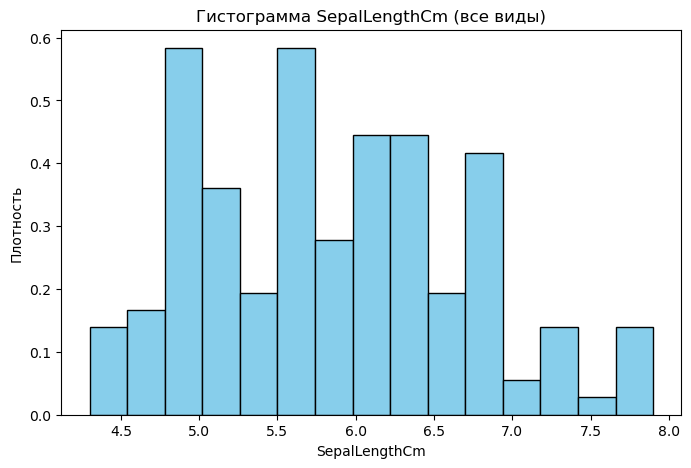

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = pd.read_csv("Iris.csv")

#Часть 1
sepal_length = iris["SepalLengthCm"]

#Точечные оценки
mean_all = np.mean(sepal_length)
var_all = np.var(sepal_length, ddof=1)

print("Мат. ожидание (все виды):", mean_all)
print("Дисперсия (все виды):", var_all)

#Гистограмма для всех видов
plt.figure(figsize=(8,5))
plt.hist(sepal_length, bins=15, color="skyblue", edgecolor="black", density=True)
plt.title("Гистограмма SepalLengthCm (все виды)")
plt.xlabel("SepalLengthCm")
plt.ylabel("Плотность")
plt.show()

Iris-setosa: мат. ожидание = 5.01, дисперсия = 0.12


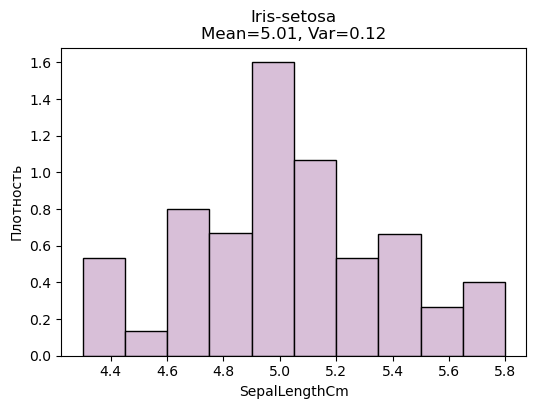

Iris-versicolor: мат. ожидание = 5.94, дисперсия = 0.27


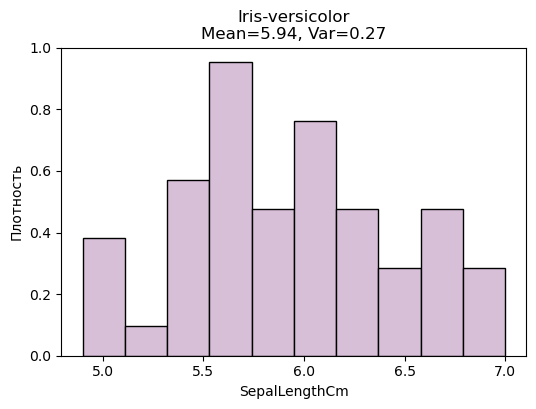

Iris-virginica: мат. ожидание = 6.59, дисперсия = 0.40


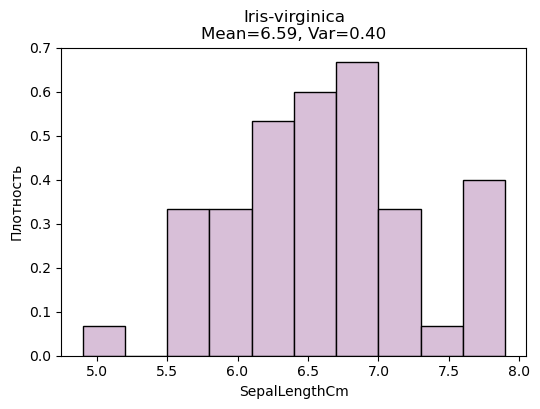

In [27]:
#Часть 2
species_groups = iris.groupby("Species")["SepalLengthCm"]

for species, values in species_groups:
    mean_val = np.mean(values)
    var_val = np.var(values, ddof=1)
    print(f"{species}: мат. ожидание = {mean_val:.2f}, дисперсия = {var_val:.2f}")
    
    #Гистограмма для каждого вида
    plt.figure(figsize=(6,4))
    plt.hist(values, bins=10, color="thistle", edgecolor="black", density=True)
    plt.title(f"{species}\nMean={mean_val:.2f}, Var={var_val:.2f}")
    plt.xlabel("SepalLengthCm")
    plt.ylabel("Плотность")
    plt.show()